# Goruntu Segmentasyonu Uctan Uca Notebook

Bu notebook, egitimden test degerlendirmesine kadar bir segmentasyon is akisini taslak olarak sunar.

## 1. Kutuphaneleri Ice Aktarma ve Ortam Ayarlari

In [13]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "torch", "torchvision", "torchaudio",
        "--index-url", "https://download.pytorch.org/whl/cpu"
    ])
    import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image

# Cihaz secimi: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Kullanilan cihaz: {device}")

Kullanilan cihaz: cpu


## 2. Veri Yollarini Tanimlama ve Dosya Dogrulama

In [14]:
# Veri klasorlerini kendi ortaminiza gore guncelleyin
base_dir = Path("./data")
train_img_dir = base_dir / "train/images"
train_mask_dir = base_dir / "train/masks"
val_img_dir = base_dir / "val/images"
val_mask_dir = base_dir / "val/masks"
test_img_dir = base_dir / "test/images"
test_mask_dir = base_dir / "test/masks"


def list_stems(folder):
    if not folder.exists():
        return set()
    return {p.stem for p in folder.iterdir() if p.is_file()}

train_img_stems = list_stems(train_img_dir)
train_mask_stems = list_stems(train_mask_dir)

missing_mask = sorted(train_img_stems - train_mask_stems)
missing_img = sorted(train_mask_stems - train_img_stems)

print("Train image sayisi:", len(train_img_stems))
print("Train mask sayisi:", len(train_mask_stems))
print("Maskesi eksik goruntu sayisi:", len(missing_mask))
print("Goruntusu eksik maske sayisi:", len(missing_img))

Train image sayisi: 0
Train mask sayisi: 0
Maskesi eksik goruntu sayisi: 0
Goruntusu eksik maske sayisi: 0


## 3. Goruntu/Mask On Isleme ve Donusumler

In [15]:
IMG_SIZE = (256, 256)

img_transform_train = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img_transform_val = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Maske etiketleri bozulmasin diye nearest interpolation kullanilir
def mask_transform(mask_pil):
    mask_resized = TF.resize(mask_pil, IMG_SIZE, interpolation=transforms.InterpolationMode.NEAREST)
    mask_np = np.array(mask_resized, dtype=np.int64)
    return torch.from_numpy(mask_np)

## 4. Ozel Dataset ve DataLoader Olusturma

In [16]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.image_transform = image_transform

        img_stems = sorted(list_stems(self.image_dir))
        mask_stems = sorted(list_stems(self.mask_dir))
        self.stems = sorted(set(img_stems).intersection(mask_stems))

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        img_path = next(self.image_dir.glob(f"{stem}.*"))
        mask_path = next(self.mask_dir.glob(f"{stem}.*"))

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.image_transform is not None:
            image = self.image_transform(image)
        mask = mask_transform(mask)
        return image, mask

batch_size = 8
num_workers = 2

train_ds = SegmentationDataset(train_img_dir, train_mask_dir, image_transform=img_transform_train)
val_ds = SegmentationDataset(val_img_dir, val_mask_dir, image_transform=img_transform_val)
test_ds = SegmentationDataset(test_img_dir, test_mask_dir, image_transform=img_transform_val)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=(len(train_ds) > 0),  # empty dataset ise RandomSampler hatasini engeller
    num_workers=num_workers,
    pin_memory=True
)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"Train/Val/Test: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

Train/Val/Test: 0/0/0


## 5. Segmentasyon Modelini Tanimlama (U-Net)

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.head(d1)


num_classes = 2
model = UNetSmall(in_channels=3, num_classes=num_classes).to(device)
print(model.__class__.__name__, "hazir")

UNetSmall hazir


## 6. Kayip Fonksiyonu ve Metrikler (Dice, IoU)

In [18]:
ce_loss = nn.CrossEntropyLoss()


def dice_score(logits, targets, eps=1e-6):
    preds = torch.argmax(logits, dim=1)
    preds = preds.float()
    targets = targets.float()
    inter = (preds * targets).sum(dim=(1, 2))
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean()


def iou_score(logits, targets, eps=1e-6):
    preds = torch.argmax(logits, dim=1)
    preds = preds.float()
    targets = targets.float()
    inter = (preds * targets).sum(dim=(1, 2))
    total = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2)) - inter
    iou = (inter + eps) / (total + eps)
    return iou.mean()


def combined_loss(logits, targets, alpha=0.5):
    ce = ce_loss(logits, targets)
    d = 1 - dice_score(logits, targets)
    return alpha * ce + (1 - alpha) * d

## 7. Egitim Dongusu ve Dogrulama Adimlari

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

num_epochs = 10
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}


def run_epoch(loader, train_mode=True):
    model.train(mode=train_mode)
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = combined_loss(logits, masks)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(logits, masks).item()
        total_iou += iou_score(logits, masks).item()

    n = max(1, len(loader))
    return total_loss / n, total_dice / n, total_iou / n


best_dice = -1.0
best_path = Path("best_unet.pth")

for epoch in range(1, num_epochs + 1):
    train_loss, _, _ = run_epoch(train_loader, train_mode=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader, train_mode=False)

    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | "
        f"val_dice: {val_dice:.4f} | val_iou: {val_iou:.4f}"
    )

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), best_path)

c:\Users\karac\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 02/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 03/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 04/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 05/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 06/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 07/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 08/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 09/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000
Epoch 10/10 | train_loss: 0.0000 | val_loss: 0.0000 | val_dice: 0.0000 | val_iou: 0.0000


## 8. Modeli Kaydetme ve En Iyi Agirliklari Yukleme

In [20]:
if best_path.exists():
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    print(f"En iyi checkpoint yuklendi: {best_path} (best_dice={best_dice:.4f})")
else:
    print("Checkpoint bulunamadi, mevcut agirliklar kullaniliyor.")

En iyi checkpoint yuklendi: best_unet.pth (best_dice=0.0000)


## 9. Tahmin Uretme ve Sonuc Gorsellestirme

In [21]:
def visualize_predictions(loader, n_samples=3):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            for i in range(images.size(0)):
                if shown >= n_samples:
                    return

                img_np = images[i].detach().cpu().permute(1, 2, 0).numpy()
                img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
                img_np = np.clip(img_np, 0, 1)

                gt_np = masks[i].detach().cpu().numpy()
                pr_np = preds[i].detach().cpu().numpy()

                plt.figure(figsize=(12, 4))
                plt.subplot(1, 3, 1)
                plt.imshow(img_np)
                plt.title("Orijinal")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(gt_np, cmap="gray")
                plt.title("Gercek Maske")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pr_np, cmap="gray")
                plt.title("Tahmin Maske")
                plt.axis("off")

                plt.tight_layout()
                plt.show()
                shown += 1


visualize_predictions(test_loader, n_samples=3)

c:\Users\karac\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 10. Test Degerlendirmesi ve Hata Analizi

In [22]:
model.eval()
test_dice_scores = []
test_iou_scores = []
error_cases = []

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(test_loader):
        images = images.to(device)
        masks = masks.to(device)
        logits = model(images)

        batch_dice = dice_score(logits, masks).item()
        batch_iou = iou_score(logits, masks).item()
        test_dice_scores.append(batch_dice)
        test_iou_scores.append(batch_iou)

        # Dusuk performansli batchleri hata analizi icin topla
        if batch_dice < 0.60 or batch_iou < 0.50:
            error_cases.append((batch_idx, batch_dice, batch_iou))

mean_test_dice = float(np.mean(test_dice_scores)) if test_dice_scores else 0.0
mean_test_iou = float(np.mean(test_iou_scores)) if test_iou_scores else 0.0

print(f"Ortalama Test Dice: {mean_test_dice:.4f}")
print(f"Ortalama Test IoU : {mean_test_iou:.4f}")

print("\nDusuk performansli ornekler (ilk 10):")
for idx, d, i in error_cases[:10]:
    print(f"Batch {idx}: Dice={d:.4f}, IoU={i:.4f}")

if not error_cases:
    print("Belirlenen esigin altinda ornek bulunamadi.")

c:\Users\karac\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ortalama Test Dice: 0.0000
Ortalama Test IoU : 0.0000

Dusuk performansli ornekler (ilk 10):
Belirlenen esigin altinda ornek bulunamadi.


## 11. YBS Davranissal Segmentasyon (Kumeleme) - Veri Hazirlama

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# temiz_veri.csv dosyasini oku
df_seg = pd.read_csv('../data/processed/temiz_veri.csv')

# Sadece segmentasyon degiskenlerini sec
X = df_seg[["income", "educ", "satfin"]].copy()

# K-Means icin olcekleme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X boyutu:", X.shape)
print("X_scaled boyutu:", X_scaled.shape)
print("\nX ilk 5 satir:")
print(X.head())

X boyutu: (7947, 3)
X_scaled boyutu: (7947, 3)

X ilk 5 satir:
   income  educ  satfin
0    11.0   8.0     3.0
1    11.0  15.0     3.0
2    12.0  13.0     3.0
3    12.0  12.0     2.0
4     9.0  14.0     2.0


## 12. Optimum Kume Sayisi - Dirsek Yontemi (Elbow Method)

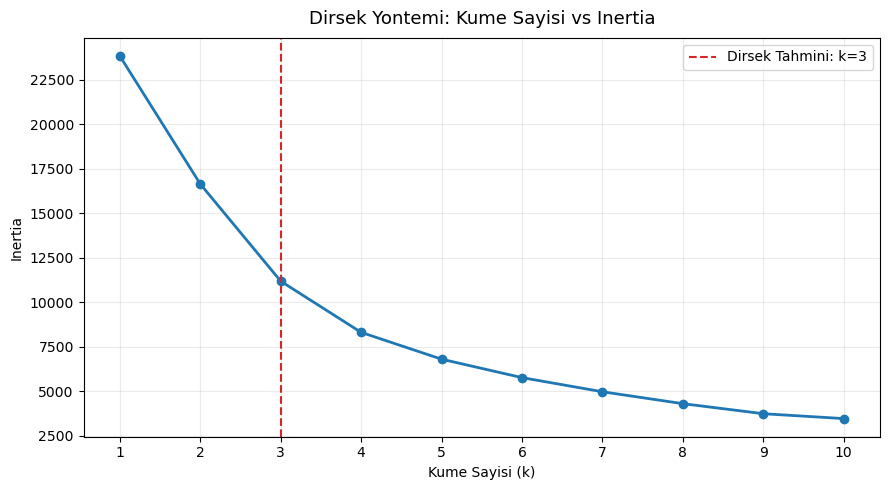


### Is Analisti Yorumu - Persona Sayisi

Grafikte inertia degeri, k arttikca dogal olarak azaliyor; ancak azalis hizinin belirgin bicimde yavasladigi kirilma noktasi **k = 3** civarinda goruluyor.

Bu nedenle hedef kitleyi operasyonel olarak **yaklasik 3 farkli persona** altinda segmentlemek en dengeli yaklasimdir:
- Daha dusuk k degerlerinde (or. 2), farkli davranis profilleri asiri genellenir.
- Daha yuksek k degerlerinde (or. 6+), segmentler fazla parcalanip aksiyon alinabilirlik duser.

Pazarlama, urun paketleme ve iletisim dili acisindan ilk fazda **3 personali segmentasyon** ile baslamak, hem anlasilir hem de olceklenebilir bir strateji sunar.


In [24]:
from sklearn.cluster import KMeans
from IPython.display import display, Markdown

k_values = list(range(1, 11))
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Basit dirsek tahmini: ikinci farkin en yuksek oldugu nokta
second_diff = np.diff(inertias, n=2)
elbow_k = k_values[int(np.argmax(second_diff)) + 1] if len(second_diff) > 0 else 3

plt.figure(figsize=(9, 5))
plt.plot(k_values, inertias, marker="o", linewidth=2, color="#1f77b4")
plt.axvline(elbow_k, linestyle="--", color="#d62728", label=f"Dirsek Tahmini: k={elbow_k}")
plt.title("Dirsek Yontemi: Kume Sayisi vs Inertia", fontsize=13, pad=10)
plt.xlabel("Kume Sayisi (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yorum_md = f"""
### Is Analisti Yorumu - Persona Sayisi

Grafikte inertia degeri, k arttikca dogal olarak azaliyor; ancak azalis hizinin belirgin bicimde yavasladigi kirilma noktasi **k = {elbow_k}** civarinda goruluyor.

Bu nedenle hedef kitleyi operasyonel olarak **yaklasik {elbow_k} farkli persona** altinda segmentlemek en dengeli yaklasimdir:
- Daha dusuk k degerlerinde (or. 2), farkli davranis profilleri asiri genellenir.
- Daha yuksek k degerlerinde (or. 6+), segmentler fazla parcalanip aksiyon alinabilirlik duser.

Pazarlama, urun paketleme ve iletisim dili acisindan ilk fazda **{elbow_k} personali segmentasyon** ile baslamak, hem anlasilir hem de olceklenebilir bir strateji sunar.
"""

display(Markdown(yorum_md))

## 13. K-Means Modeli ile Segment Etiketlerinin Uretilmesi

In [25]:
# Dirsek yonteminden gelen optimum kume sayisi
KUME_SAYISI = elbow_k

# K-Means modelini kur, egit ve etiketleri uret
kmeans_final = KMeans(n_clusters=KUME_SAYISI, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Etiketleri orijinal (olceklendirilmemis) veri setine ekle
df_seg["Segment"] = cluster_labels

print(f"Secilen optimum kume sayisi: {KUME_SAYISI}")
print("\nSegment dagilimi:")
print(df_seg["Segment"].value_counts().sort_index())
print("\nVeri onizleme (income, educ, satfin, Segment):")
print(df_seg[["income", "educ", "satfin", "Segment"]].head())

Secilen optimum kume sayisi: 3

Segment dagilimi:
Segment
0    3552
1    3913
2     482
Name: count, dtype: int64

Veri onizleme (income, educ, satfin, Segment):
   income  educ  satfin  Segment
0    11.0   8.0     3.0        1
1    11.0  15.0     3.0        1
2    12.0  13.0     3.0        1
3    12.0  12.0     2.0        1
4     9.0  14.0     2.0        1


## 14. Segment Profilleme, Gorsellestirme ve Pazarlama Stratejisi

Segment Ozet Tablosu (Ortalama Degerler):


,income,educ,satfin
Segment,,,
0,11.847691,16.089245,1.451014
1,11.348837,12.777920,2.495528
2,3.157676,12.128631,2.288382


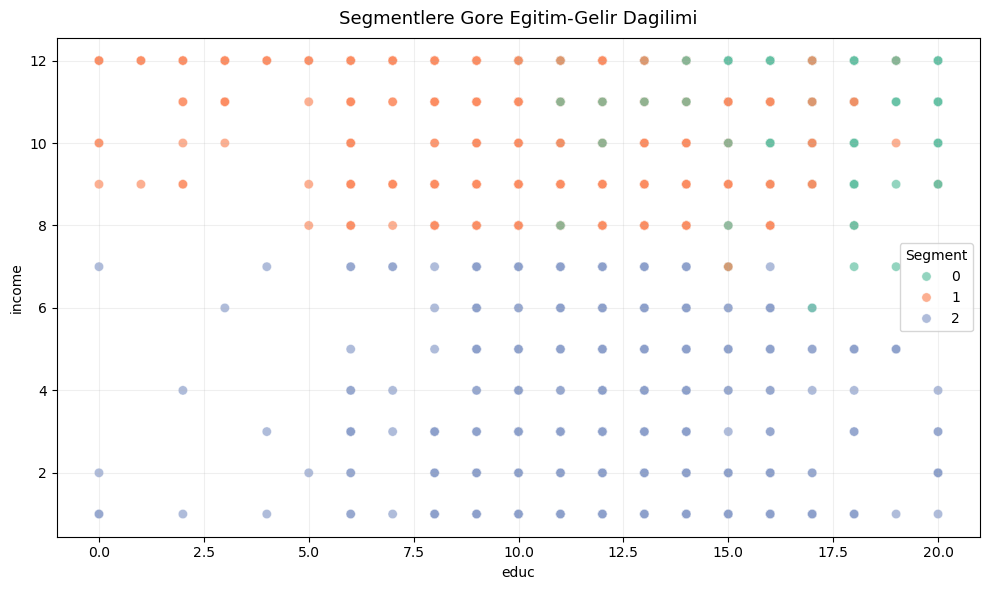


### Pazarlama / YBS Analisti Yorumu

Asagidaki segment isimlendirmesi, ozet tablo ortalamalarina dayali olarak is degeri uretme odagiyla yapilmistir:

- **Segment 0 - Gelisime Acik Profil**: income=11.85, educ=16.09, satfin=1.45
- **Segment 1 - Gelisime Acik Profil**: income=11.35, educ=12.78, satfin=2.50
- **Segment 2 - Dusuk Tatmin / Yuksek Risk**: income=3.16, educ=12.13, satfin=2.29

### Segment Bazli Strateji Onerileri

- **VIP Hedef Kitle**:
  Premium paketler, ozel danismanlik, sadakat odakli capraz satis kampanyalari uygulanmali.
- **Gelisime Acik Profil**:
  Egitici icerikler, avantajli deneme paketleri ve asamali tekliflerle ust segmente tasinmali.
- **Dusuk Tatmin / Yuksek Risk**:
  Fiyat hassasiyeti yuksek teklifler, memnuniyet artirici hizli geri bildirim mekanizmalari ve churn onleyici aksiyonlar devreye alinmali.

Bu yaklasimla kurumlar butceyi daha verimli dagitip, hem gelir artisi hem de musteri bagliligi acisindan olculebilir kazanc elde edebilir.


In [26]:
import seaborn as sns
from IPython.display import display, Markdown

# Segment bazli ozet tablo
segment_ozet = (
    df_seg.groupby("Segment")[["income", "educ", "satfin"]]
    .mean()
    .sort_values(["income", "educ"], ascending=False)
)

print("Segment Ozet Tablosu (Ortalama Degerler):")
display(segment_ozet)

# Segmentleri isimlendirme mantigi
segment_isimleri = {}
for seg, row in segment_ozet.iterrows():
    if row["income"] >= segment_ozet["income"].quantile(0.67) and row["satfin"] >= segment_ozet["satfin"].median():
        segment_isimleri[seg] = "VIP Hedef Kitle"
    elif row["income"] <= segment_ozet["income"].quantile(0.33) and row["satfin"] <= segment_ozet["satfin"].median():
        segment_isimleri[seg] = "Dusuk Tatmin / Yuksek Risk"
    else:
        segment_isimleri[seg] = "Gelisime Acik Profil"

# Gorsellestirme icin isim kolonunu ekle
df_seg["Segment_Adi"] = df_seg["Segment"].map(segment_isimleri)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_seg,
    x="educ",
    y="income",
    hue="Segment",
    palette="Set2",
    alpha=0.70,
    s=45,
    edgecolor="white",
    linewidth=0.4
)
plt.title("Segmentlere Gore Egitim-Gelir Dagilimi", fontsize=13, pad=10)
plt.xlabel("educ")
plt.ylabel("income")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

# Is dunyasina uygun yorumlar (markdown)
lines = []
for seg, ad in segment_isimleri.items():
    m = segment_ozet.loc[seg]
    lines.append(
        f"- **Segment {seg} - {ad}**: income={m['income']:.2f}, educ={m['educ']:.2f}, satfin={m['satfin']:.2f}"
    )

yorum_segment_md = f"""
### Pazarlama / YBS Analisti Yorumu

Asagidaki segment isimlendirmesi, ozet tablo ortalamalarina dayali olarak is degeri uretme odagiyla yapilmistir:

{chr(10).join(lines)}

### Segment Bazli Strateji Onerileri

- **VIP Hedef Kitle**:
  Premium paketler, ozel danismanlik, sadakat odakli capraz satis kampanyalari uygulanmali.
- **Gelisime Acik Profil**:
  Egitici icerikler, avantajli deneme paketleri ve asamali tekliflerle ust segmente tasinmali.
- **Dusuk Tatmin / Yuksek Risk**:
  Fiyat hassasiyeti yuksek teklifler, memnuniyet artirici hizli geri bildirim mekanizmalari ve churn onleyici aksiyonlar devreye alinmali.

Bu yaklasimla kurumlar butceyi daha verimli dagitip, hem gelir artisi hem de musteri bagliligi acisindan olculebilir kazanc elde edebilir.
"""

display(Markdown(yorum_segment_md))

In [27]:
# README icin grafikleri dosyaya kaydet
import os
os.makedirs("assets", exist_ok=True)

# Elbow grafigi
plt.figure(figsize=(9, 5))
plt.plot(k_values, inertias, marker="o", linewidth=2, color="#1f77b4")
plt.axvline(elbow_k, linestyle="--", color="#d62728", label=f"Dirsek Tahmini: k={elbow_k}")
plt.title("Dirsek Yontemi: Kume Sayisi vs Inertia", fontsize=13, pad=10)
plt.xlabel("Kume Sayisi (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("assets/elbow_method.png", dpi=160)
plt.close()

# Segment scatter grafigi
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_seg,
    x="educ",
    y="income",
    hue="Segment",
    palette="Set2",
    alpha=0.70,
    s=45,
    edgecolor="white",
    linewidth=0.4
)
plt.title("Segmentlere Gore Egitim-Gelir Dagilimi", fontsize=13, pad=10)
plt.xlabel("educ")
plt.ylabel("income")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.savefig("assets/segment_scatter.png", dpi=160)
plt.close()

print("Gorseller kaydedildi: assets/elbow_method.png, assets/segment_scatter.png")

Gorseller kaydedildi: assets/elbow_method.png, assets/segment_scatter.png
